# DSM GA — Hyperparameter Tuning with Optuna

Uses Optuna to find optimal parameters for the DSM genetic algorithm.

## How to use
1. Set `PARAM_GROUP` in the configuration cell to one of:
   - `'weights'` — alpha, beta, gamma, delta
   - `'ga_operators'` — population_size, cxpb, mutpb, tournsize
   - `'clustering'` — target_clusters, max_clusters, consolidation_mode
   - `'fitness_and_clustering'` — weights + clustering
   - `'all'` — every parameter
2. Adjust `TRIAL_GENERATIONS`, `TRIAL_POPULATION`, `N_TRIALS` for speed vs. quality
3. Run all cells
4. The final cell runs a full GA with the best found parameters and exports to Excel

In [1]:
!uv sync

Resolved 127 packages in 3ms
Audited 122 packages in 16ms


In [2]:
!uv add optuna scikit-learn openpyxl

Resolved 127 packages in 3ms
Audited 122 packages in 23ms


In [3]:
!uv pip install optuna scikit-learn openpyxl

Audited 3 packages in 14ms


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import optuna
from dataclasses import replace as dc_replace
from dsm_ga import load_data, GAConfig, run_ga

optuna.logging.set_verbosity(optuna.logging.WARNING)

C:\git\DSM2026\Genetic algorithm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

In [5]:
freq_csv_path   = "consolidation_potential_DSM_scenario1_interaction_frequency.csv"
consol_csv_path = "consolidation_potential_DSM_scenario1_SA4_FTE2_2026-08-04-12h27.csv"

DSM_freq, DSM_consol, units, DSM_header_list = load_data(freq_csv_path, consol_csv_path)
print(f"Loaded {len(units)} units")

Loaded 30 units


## Tuning configuration

In [6]:
# ── Parameter group ─────────────────────────────────────────────────────────
# Choose ONE of:
#   'weights'               — alpha, beta, gamma, delta
#   'ga_operators'          — population_size, cxpb, mutpb, tournsize
#   'clustering'            — target_clusters, max_clusters, consolidation_mode
#   'fitness_and_clustering'— weights + clustering
#   'all'                   — every parameter
PARAM_GROUP = "weights"

# ── Trial budget ─────────────────────────────────────────────────────────────
TRIAL_GENERATIONS = 100   # reduced GA run per trial (full run uses config.n_generations)
TRIAL_POPULATION  = 100   # reduced population per trial
N_TRIALS          = 50    # number of Optuna trials
N_JOBS            = 1     # set to -1 for parallel trials

# ── Base config (frozen params stay at these values) ─────────────────────────
base_config = GAConfig()

## Objective function

In [7]:
VALID_GROUPS = {"weights", "ga_operators", "clustering", "fitness_and_clustering", "all"}
assert PARAM_GROUP in VALID_GROUPS, f"PARAM_GROUP must be one of {VALID_GROUPS}"


def _suggest_weights(trial):
    """Sample 4 weights that sum to <= 1.0."""
    raw = [trial.suggest_float(f"raw_w{i}", 0.0, 1.0) for i in range(4)]
    total = sum(raw)
    if total > 1.0:
        raw = [w / total * 0.95 for w in raw]
    return raw[0], raw[1], raw[2], raw[3]


def build_trial_config(trial, param_group: str, base: GAConfig) -> GAConfig:
    """Return a GAConfig with trial-suggested values merged over base."""
    kwargs = {}

    if param_group in ("weights", "fitness_and_clustering", "all"):
        a, b, g, d = _suggest_weights(trial)
        kwargs["alpha"] = a
        kwargs["beta"]  = b
        kwargs["gamma"] = g
        kwargs["delta"] = d

    if param_group in ("clustering", "fitness_and_clustering", "all"):
        target = trial.suggest_int("target_clusters", 3, 15)
        kwargs["target_clusters"]    = target
        kwargs["max_clusters"]       = trial.suggest_int("max_clusters", target, 20)
        kwargs["consolidation_mode"] = trial.suggest_categorical(
            "consolidation_mode", ["once", "directional"]
        )

    if param_group in ("ga_operators", "all"):
        kwargs["population_size"] = trial.suggest_int("population_size", 50, 500, step=50)
        kwargs["cxpb"]            = trial.suggest_float("cxpb", 0.2, 0.9)
        kwargs["mutpb"]           = trial.suggest_float("mutpb", 0.01, 0.3)
        kwargs["tournsize"]        = trial.suggest_int("tournsize", 2, 10)

    return dc_replace(base, **kwargs)


def objective(trial):
    cfg = build_trial_config(trial, PARAM_GROUP, base_config)
    cfg = dc_replace(cfg, n_generations=TRIAL_GENERATIONS, population_size=TRIAL_POPULATION)
    _, _, fitness = run_ga(DSM_freq, DSM_consol, cfg, verbose=False)
    return fitness

## Run study

In [8]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=N_TRIALS, n_jobs=N_JOBS, show_progress_bar=True)

print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best fitness: {study.best_value:.4f}")
print("\nBest parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 34. Best value: 33.6642: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [02:21<00:00,  2.82s/it]


Best trial: #34
Best fitness: 33.6642

Best parameters:
  raw_w0: 0.5425365458969557
  raw_w1: 0.004909041470911007
  raw_w2: 0.9489417821284548
  raw_w3: 0.4245355079441723


## Results visualisation

C:\Users\Lanze\AppData\Local\Temp\ipykernel_47616\1661535257.py:8: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)
C:\Users\Lanze\AppData\Local\Temp\ipykernel_47616\1661535257.py:11: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


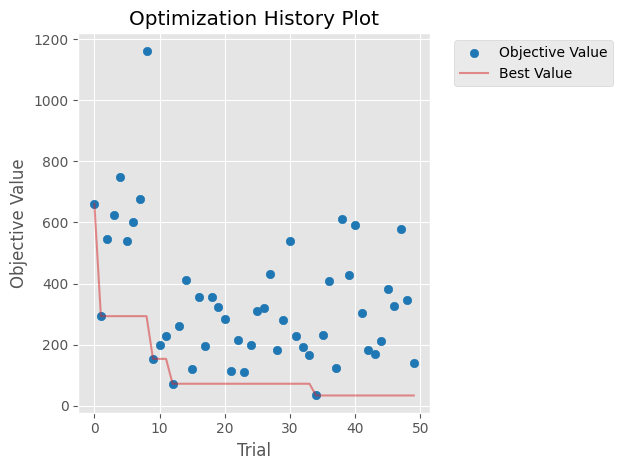

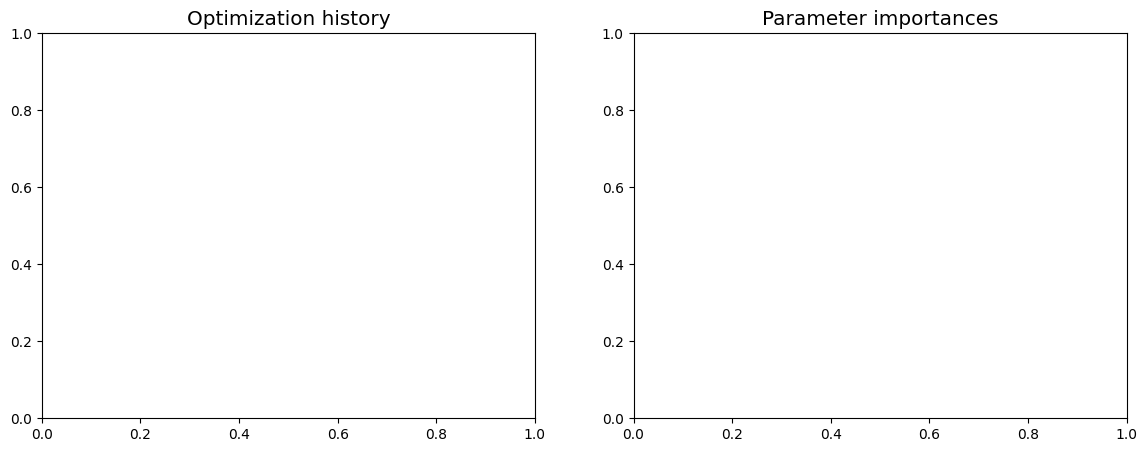

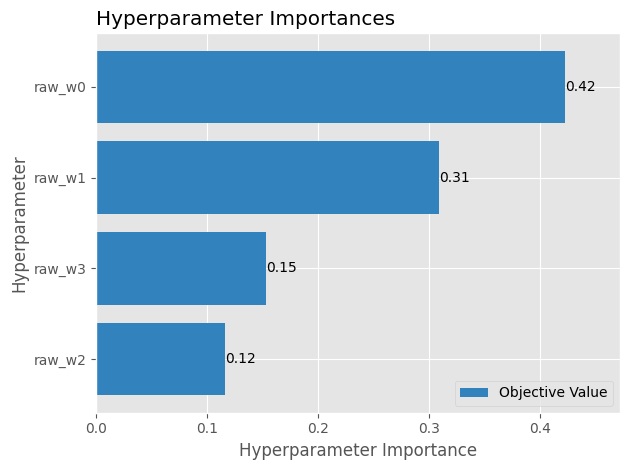

In [9]:
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.sca(axes[0])
plot_optimization_history(study)
axes[0].set_title("Optimization history")
plt.sca(axes[1])
plot_param_importances(study)
axes[1].set_title("Parameter importances")
plt.tight_layout()
plt.show()

## Full run with best parameters

Applies the best Optuna parameters on top of `base_config` and runs a full-length GA, then exports to Excel.

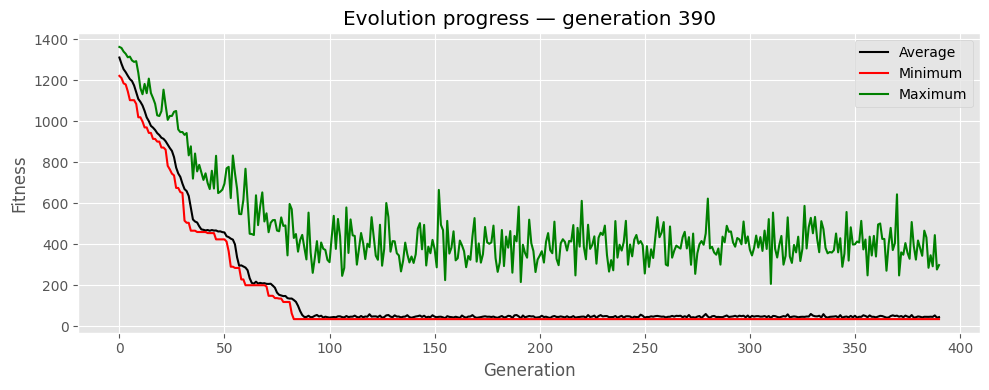

Gen  390 | Avg: 43.5410 | Min: 33.6642 | Max: 297.6609

Final fitness: 33.6642
Best solution: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [10]:
best_config = build_trial_config(study.best_trial, PARAM_GROUP, base_config)
print("Running full GA with best config:")
print(best_config)

best, logbook, final_fitness = run_ga(
    DSM_freq, DSM_consol, best_config, verbose=True
)
print(f"\nFinal fitness: {final_fitness:.4f}")
print(f"Best solution: {best}")

In [11]:
from IPython.display import display

NUMBER_OF_DSM_ELEMENTS = len(units)
group_assignments = list(best)
sorted_indices = sorted(range(NUMBER_OF_DSM_ELEMENTS), key=lambda i: group_assignments[i])
sorted_units  = [DSM_header_list[i] for i in sorted_indices]
sorted_groups = [group_assignments[i] for i in sorted_indices]

df_optimized_grouping = pd.DataFrame({
    'Unit Name': sorted_units,
    'Cluster':   [f'Cluster {g}' for g in sorted_groups],
})
display(df_optimized_grouping)

csv_file = consol_csv_path.replace('.csv', '')
output_path = csv_file + f'_tuned_{PARAM_GROUP}_optimized.xlsx'

DSM_reordered = DSM_freq.iloc[sorted_indices].iloc[:, sorted_indices].copy()
DSM_reordered.index = DSM_reordered.columns = sorted_units
DSM_consol_reordered = DSM_consol.iloc[sorted_indices].iloc[:, sorted_indices].copy()
DSM_consol_reordered.index = DSM_consol_reordered.columns = sorted_units

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    DSM_reordered.to_excel(writer, sheet_name='dsm_optimized')
    DSM_consol_reordered.to_excel(writer, sheet_name='dsm_consolidation')
    df_optimized_grouping.to_excel(writer, sheet_name='grouping')
    DSM_freq.to_excel(writer, sheet_name='interaction_frequency')
    DSM_consol.to_excel(writer, sheet_name='consolidation_potential')

print(f'Exported to {output_path}')

,Unit Name,Cluster
0,Clinical Research Division,Cluster 0
1,Clinical Strategy Division,Cluster 0
2,Clinical Strategy Group,Cluster 0
3,Medical Communications Office,Cluster 0
4,Medical Evaluation Unit 1,Cluster 0
5,Medical Evaluation Unit 2,Cluster 0
6,Medical Evaluation Unit 3,Cluster 0
7,Medical Excellence Office,Cluster 0
8,Medical Excellence Team,Cluster 0
9,Medical Governance Office,Cluster 0


Exported to consolidation_potential_DSM_scenario1_SA4_FTE2_2026-08-04-12h27_tuned_weights_optimized.xlsx


Saved: consolidation_potential_DSM_scenario1_SA4_FTE2_2026-08-04-12h27_dsm_figure.png


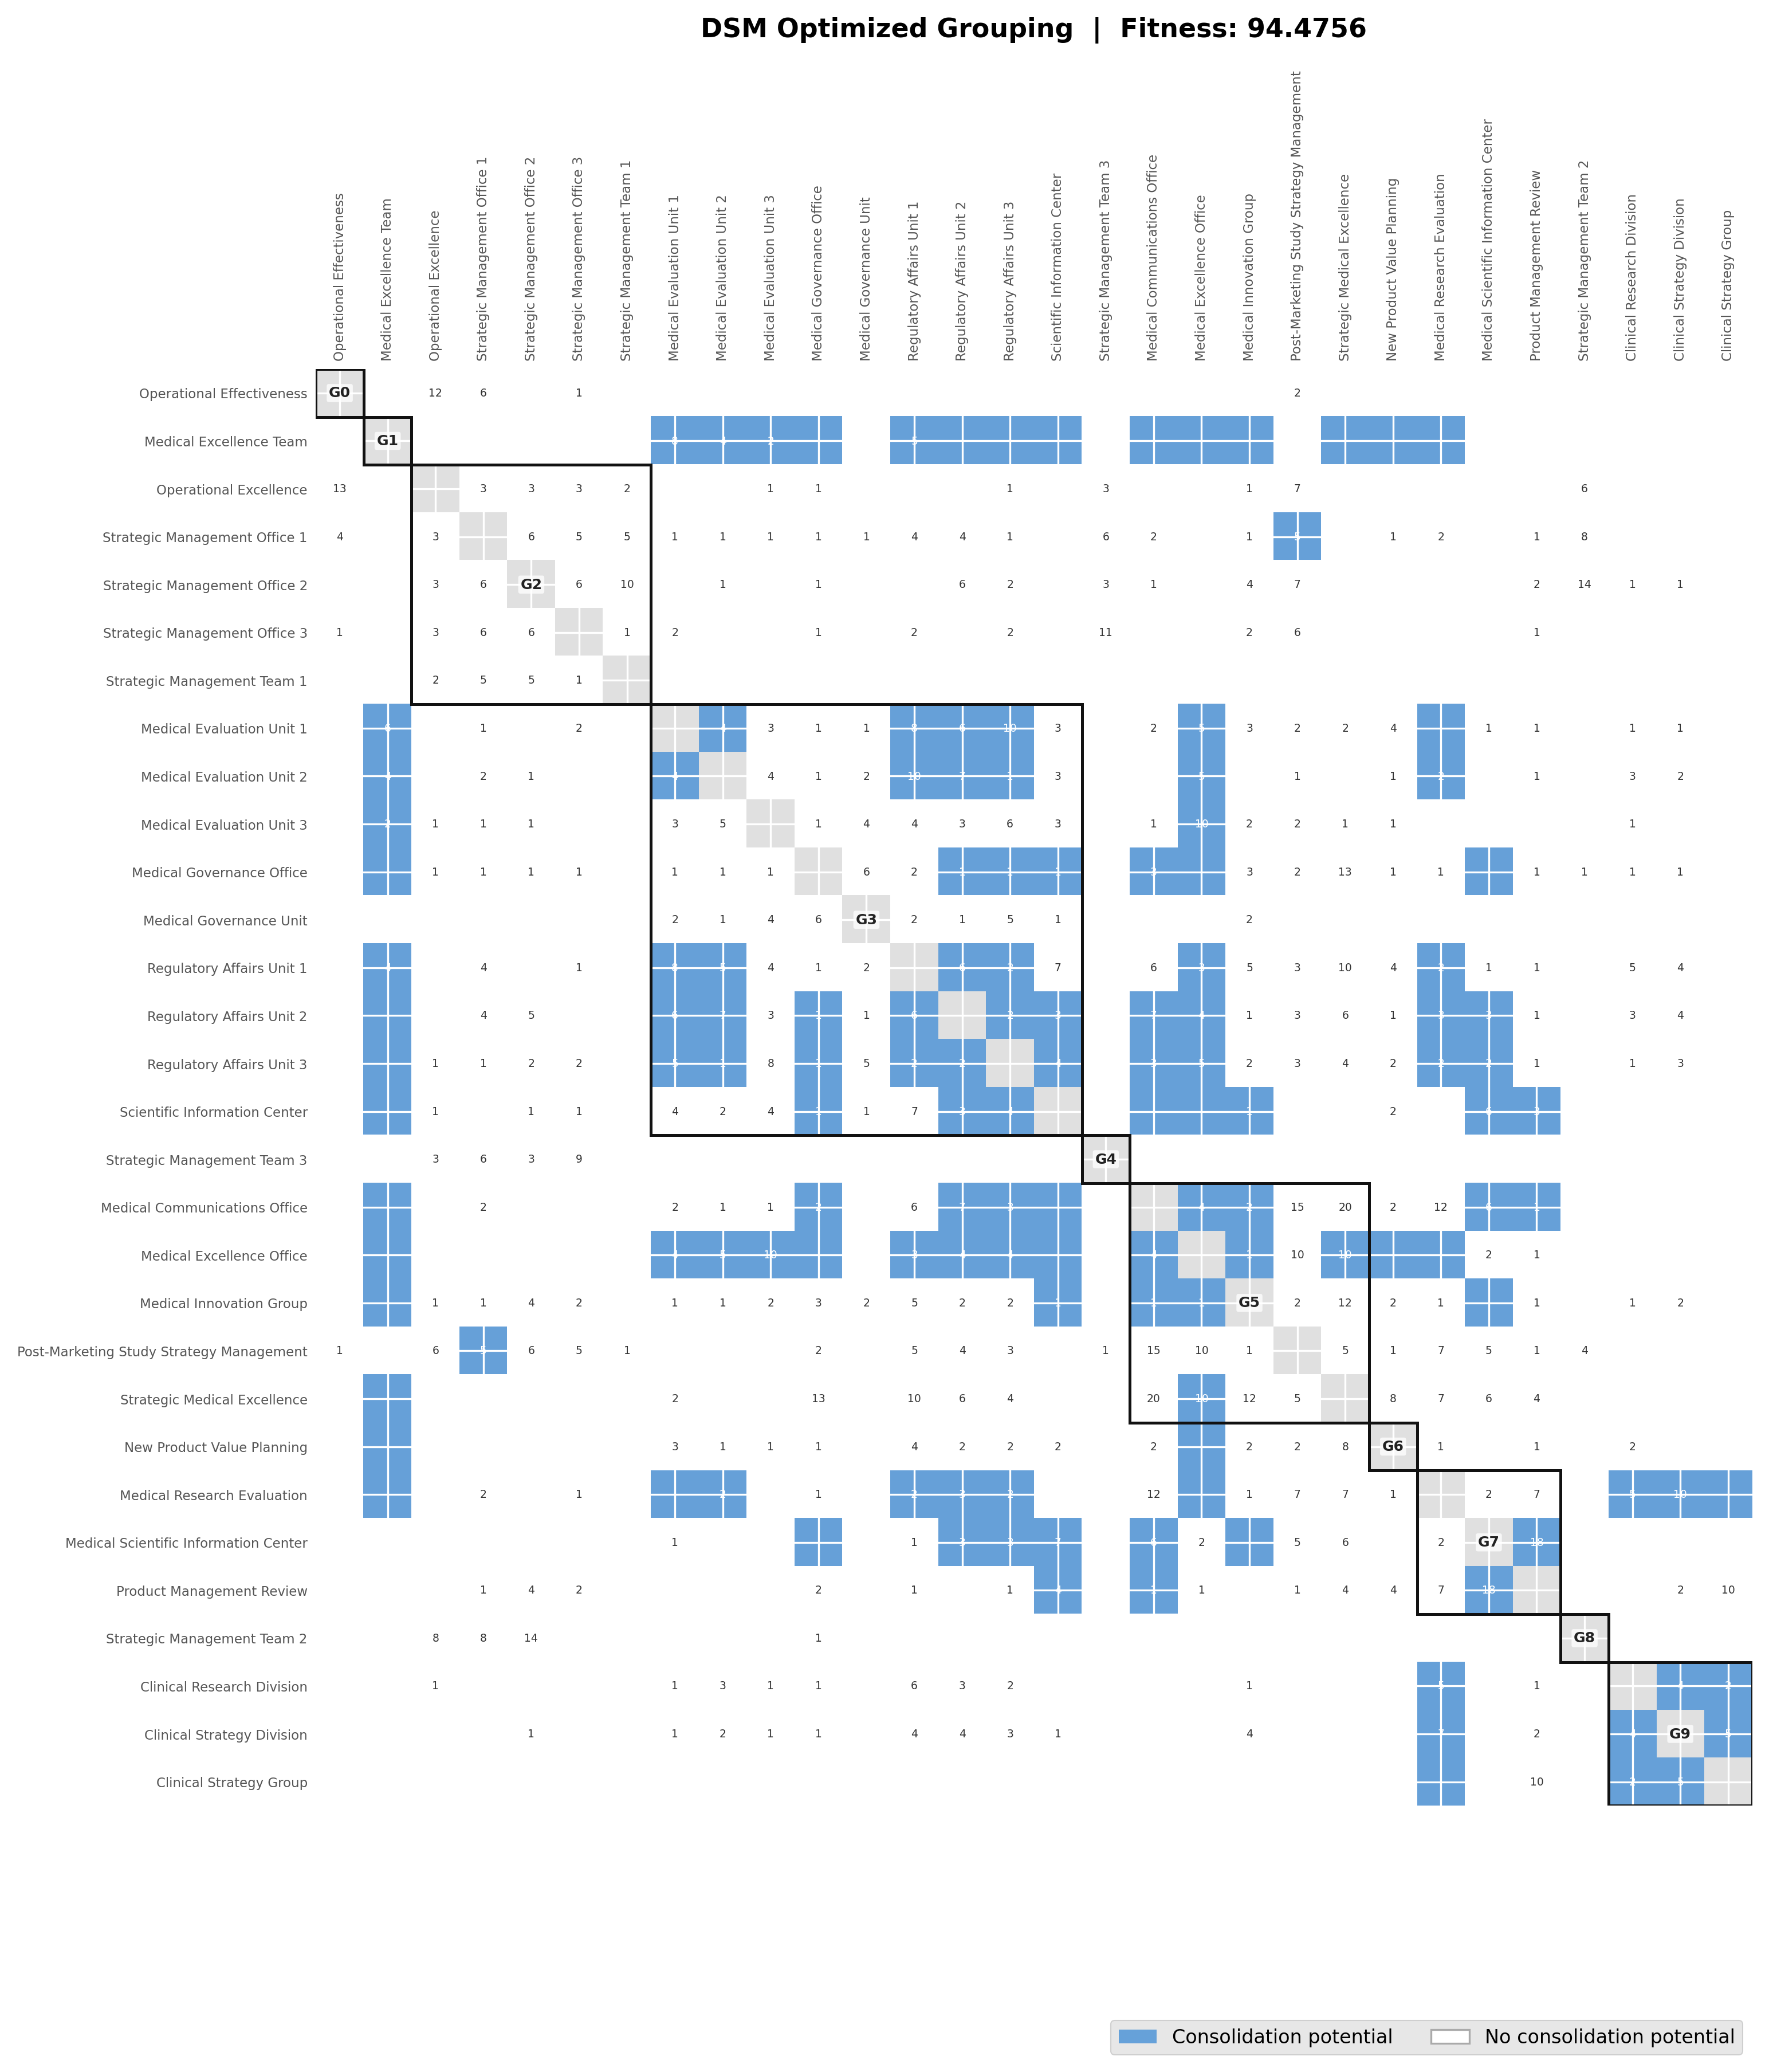

In [12]:
# Publication-quality DSM figure
def plot_dsm_paper(freq_df, consol_df, units, groups, title=None, dpi=300, save_path=None):
    import matplotlib.patches as patches
    import numpy as np
    n = len(units)
    unique_clusters = sorted(set(groups))

    c_start, c_end = {}, {}
    for idx, g in enumerate(groups):
        if g not in c_start: c_start[g] = idx
        c_end[g] = idx

    CONSOL_COLOR = [0.40, 0.63, 0.85, 1.0]
    DIAG_COLOR   = [0.88, 0.88, 0.88, 1.0]
    WHITE        = [1.00, 1.00, 1.00, 1.0]

    rgba   = np.tile(WHITE, (n, n, 1))
    freq   = freq_df.values.astype(float)
    consol = consol_df.values.astype(float)
    for i in range(n):
        for j in range(n):
            if i == j:
                rgba[i, j] = DIAG_COLOR
            elif consol[i, j] == 1:
                rgba[i, j] = CONSOL_COLOR

    cell_size = max(0.28, min(0.45, 10.0 / n))
    fig_size  = max(8, n * cell_size + 2.5)

    fig, ax = plt.subplots(figsize=(fig_size, fig_size), dpi=dpi)
    ax.imshow(rgba, aspect='equal', interpolation='none', origin='upper')

    fontsize = max(4.5, min(8.0, 95.0 / n))
    for i in range(n):
        for j in range(n):
            if i != j and freq[i, j] > 0:
                on_blue = consol[i, j] == 1
                ax.text(j, i, str(int(freq[i, j])),
                        ha='center', va='center', fontsize=fontsize,
                        color='white' if on_blue else '#333333',
                        fontfamily='sans-serif')

    lw = max(1.2, min(2.0, 14.0 / n))
    for g in unique_clusters:
        s, e = c_start[g], c_end[g]
        rect = patches.Rectangle(
            (s - 0.5, s - 0.5), e - s + 1, e - s + 1,
            linewidth=lw, edgecolor='#111111', facecolor='none', zorder=4)
        ax.add_patch(rect)

    lbl_fs = max(5.5, min(8.5, 85.0 / n))
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(units, rotation=90, fontsize=lbl_fs, ha='center', fontfamily='sans-serif')
    ax.set_yticklabels(units, fontsize=lbl_fs, fontfamily='sans-serif')
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False,
                   left=True, labelleft=True, length=0)
    ax.xaxis.set_label_position('top')
    for spine in ax.spines.values():
        spine.set_visible(False)

    clbl_fs = max(6, min(10, 100.0 / n))
    for g in unique_clusters:
        s, e = c_start[g], c_end[g]
        ax.text((s + e) / 2.0, (s + e) / 2.0, 'G' + str(g),
                ha='center', va='center', fontsize=clbl_fs,
                fontweight='bold', color='#222222', zorder=5,
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.75, linewidth=0))

    if title:
        ax.set_title(title, fontsize=11, fontweight='bold', pad=14, fontfamily='sans-serif')

    from matplotlib.patches import Patch
    ax.legend(
        handles=[
            Patch(facecolor=CONSOL_COLOR[:3], edgecolor='none', label='Consolidation potential'),
            Patch(facecolor='white', edgecolor='#aaaaaa', linewidth=0.8, label='No consolidation potential'),
        ],
        loc='lower right', bbox_to_anchor=(1.0, -0.18),
        fontsize=8, frameon=True, framealpha=0.9, edgecolor='#cccccc', ncol=2,
    )

    plt.tight_layout(pad=1.5)
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print('Saved: ' + save_path)
    plt.show()
    return fig


fig_dsm = plot_dsm_paper(
    DSM_reordered, DSM_consol_reordered,
    sorted_units, sorted_groups,
    title='DSM Optimized Grouping  |  Fitness: ' + str(round(final_fitness, 4)),
    dpi=300,
    save_path=csv_file + '_dsm_figure.png',
)
